# Animal Species Recognition Framework

This notebook is a development of an image classification system to identify the species of an animal using Convolutional Neural Networks (CNNs) and Transfer Learning. The project aims to classify images from the Animals-10 dataset into 10 different animal classes.


# Dataset link = https://www.kaggle.com/datasets/alessiocorrado99/animals10

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil

source = "/content/drive/MyDrive/dataset/archive/raw-img"
destination = "/content/raw-img"

shutil.copytree(source, destination)

print("Dataset copied successfully!")

Dataset copied successfully!


In [ ]:
# Import Required Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
# Load Dataset
dataset_path = "/content/raw-img"

print(os.listdir(dataset_path))

['cane', 'gatto', 'elefante', 'farfalla', 'scoiattolo', 'cavallo', 'mucca', 'pecora', 'gallina', 'ragno']


## Dataset Exploration

The dataset is then explored to gain information about the number of animal classes in the dataset and to visualize sample images of them. This will assist in checking the data has been loaded correctly and will give you an idea of what the classification categories are.

In [ ]:
# Count number of classes

classes = sorted(os.listdir(dataset_path))

print(f"Number of classes: {len(classes)}")
print("\nClasses:")

for cls in classes:
    print("-", cls)

Number of classes: 10

Classes:
- cane
- cavallo
- elefante
- farfalla
- gallina
- gatto
- mucca
- pecora
- ragno
- scoiattolo


## Visualize Sample Images


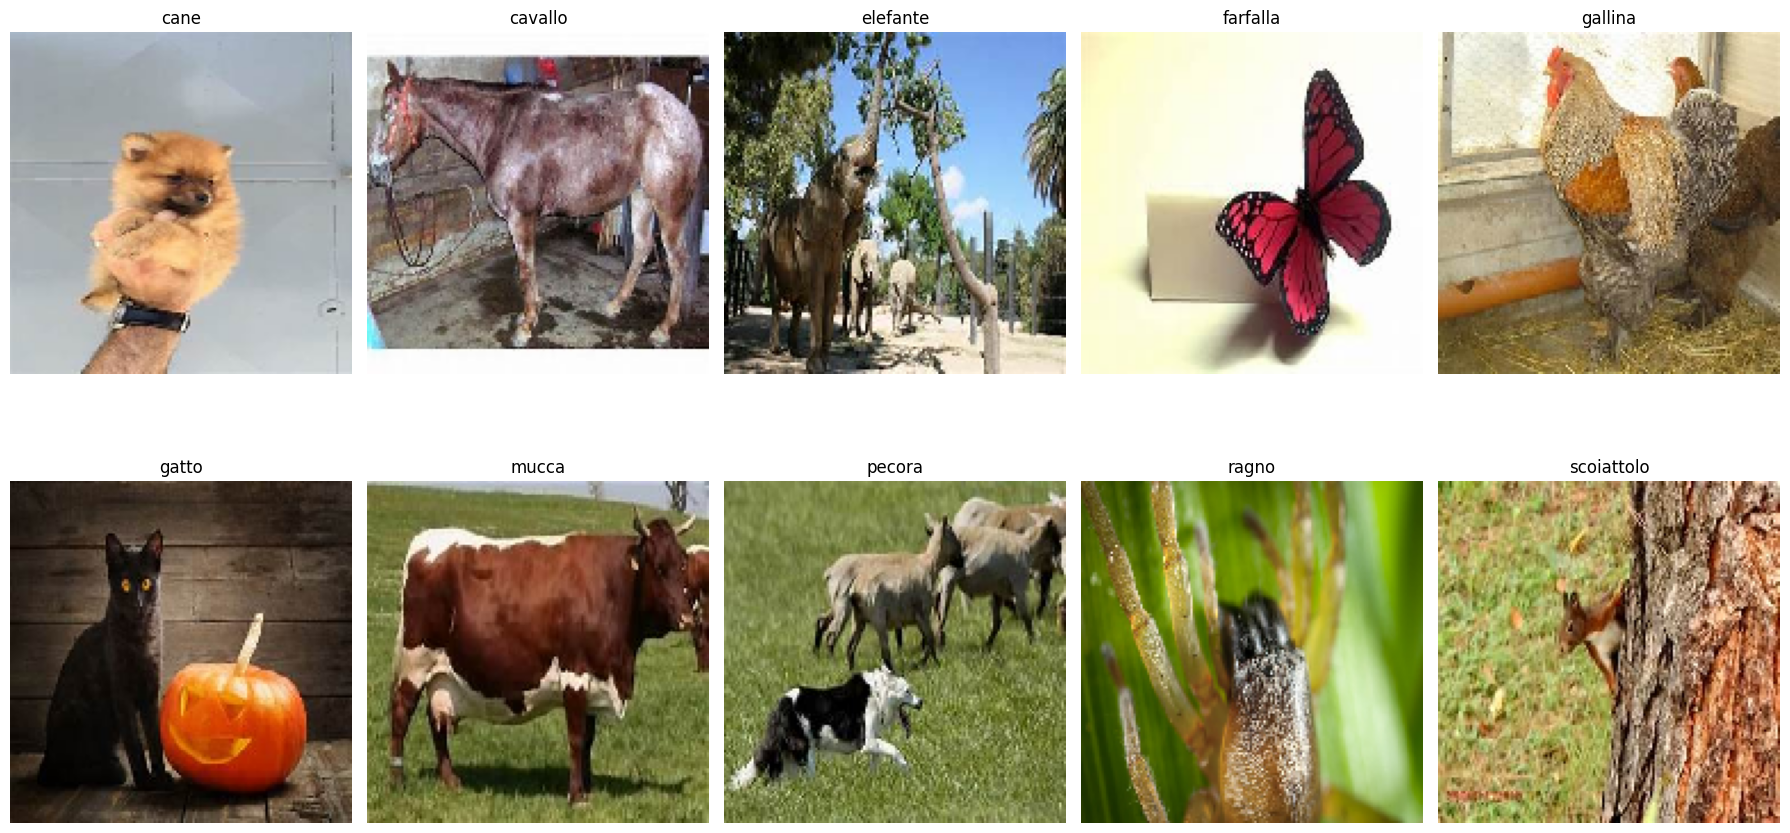

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(18,10))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    img = load_img(image_path, target_size=(150,150))

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Dataset Statistics

The next section counts the number of images to be found in each animal class. It's crucial to have an understanding of the class distribution to be aware of if there's any imbalance that could impact the performance of the model.

In [ ]:
import pandas as pd

class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(class_path))

df = pd.DataFrame({
    "Animal Class": class_counts.keys(),
    "Number of Images": class_counts.values()
})

df

,Animal Class,Number of Images
0,cane,4863
1,cavallo,2623
2,elefante,1446
3,farfalla,2112
4,gallina,3098
5,gatto,1668
6,mucca,1866
7,pecora,1820
8,ragno,4821
9,scoiattolo,1862


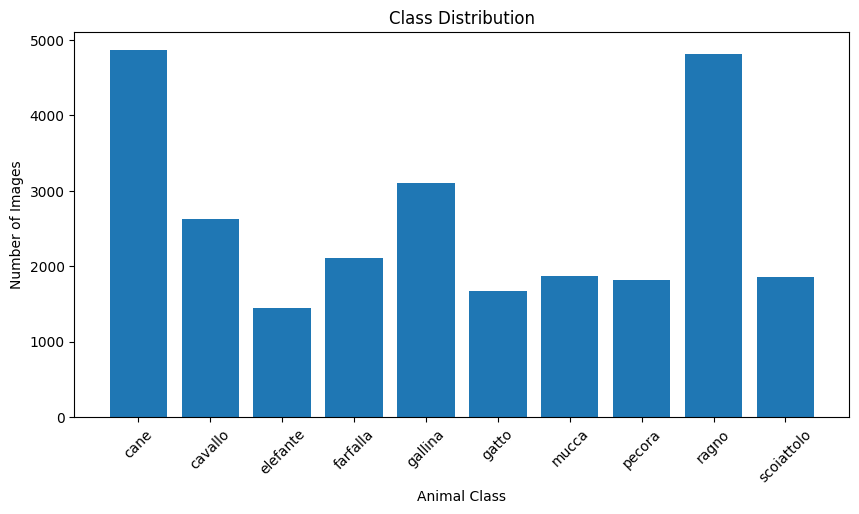

In [ ]:
# Class Distribution
plt.figure(figsize=(10,5))

plt.bar(df["Animal Class"], df["Number of Images"])

plt.xticks(rotation=45)
plt.xlabel("Animal Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.show()

## Data Preprocessing

Preprocessing of the data prior to training is performed to make the image size and values consistent. Images are resized, sized at 224×224, and normalized. Data Augmentation is also employed to enhance model generalization and prevent over-fitting.

In [ ]:
# Image parameters

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

## Create Training, Validation, and Test Sets

The data is split into the training set, validation set and test set. Random transformations are added to the data during training, and only rescaled during validation and test.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.20,
    height_shift_range=0.20,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

## Generate Training Dataset

The training dataset is loaded from the directory using real-time data augmentation.

In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

Found 20947 images belonging to 10 classes.


## Generate Validation Dataset

The remaining images (not augmented) are used to create the validation dataset.

In [ ]:
validation_generator = test_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 5232 images belonging to 10 classes.


## Verify Dataset Information

Below shows the number of images in the training set and the class label detected for them, as well as the number of images in the validation set and the class label detected for them.

In [ ]:
print("Training Images :", train_generator.samples)
print("Validation Images :", validation_generator.samples)

print("\nClass Indices")
print(train_generator.class_indices)

Training Images : 20947
Validation Images : 5232

Class Indices
{'cane': 0, 'cavallo': 1, 'elefante': 2, 'farfalla': 3, 'gallina': 4, 'gatto': 5, 'mucca': 6, 'pecora': 7, 'ragno': 8, 'scoiattolo': 9}


## Visualize Augmented Images

Random images with augmented images are shown to confirm proper processing and augmentation.

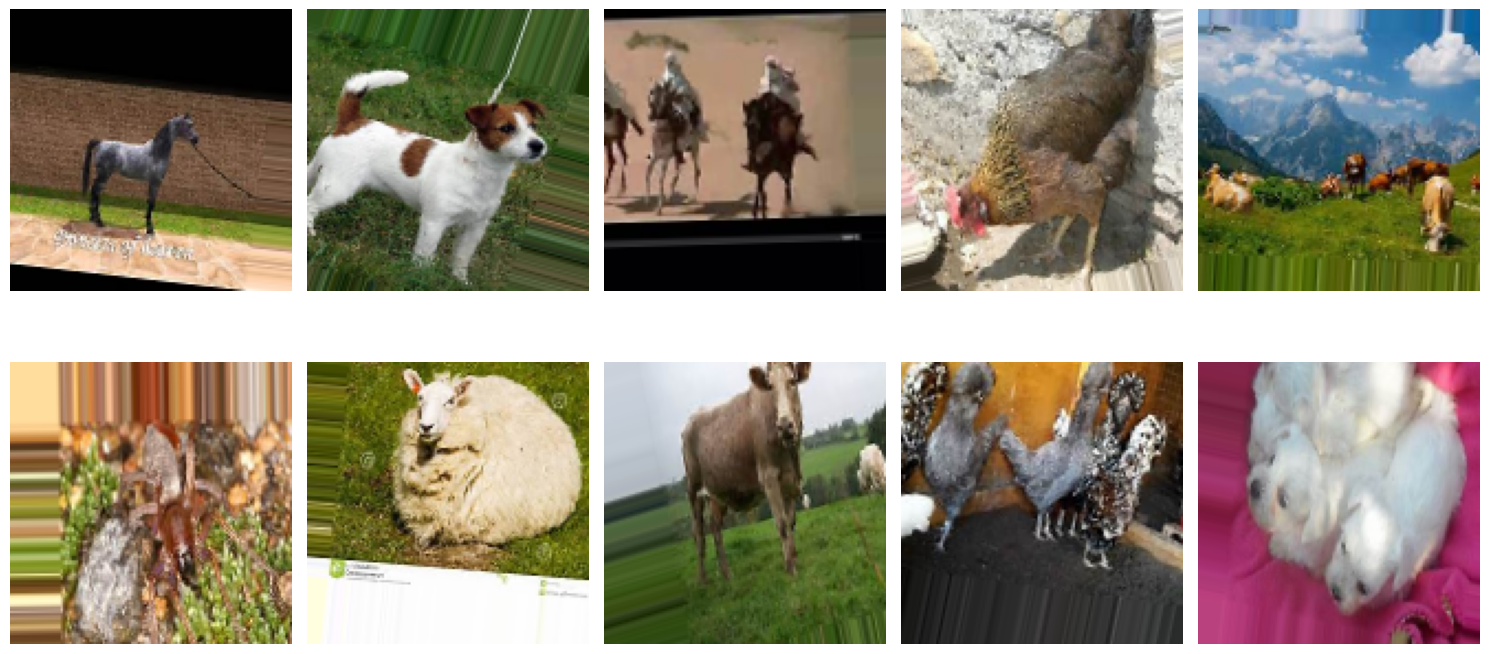

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(15,8))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Build Custom CNN Model

A special Convolutional Neural Network (CNN) is created to classify animal species. Architecture: Multiple Convolutional layers, Multiple Pooling layers and Fully connected layers for multi-class classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')

])

## Model Summary

The model summary gives you information about the architecture of your model, such as the shape of the output for each layer, and the number of trainable parameters.

In [ ]:
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,602 (24.87 MB)

 Trainable params: 6,518,602 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Train the CNN Model

The CNN model is trained using the augmented training dataset and validated using the validation dataset.

In [ ]:
history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 136s 198ms/step - accuracy: 0.2770 - loss: 2.0231 - val_accuracy: 0.3509 - val_loss: 1.8412
Epoch 2/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 125s 191ms/step - accuracy: 0.4045 - loss: 1.7191 - val_accuracy: 0.4102 - val_loss: 1.6380
Epoch 3/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 151s 204ms/step - accuracy: 0.4678 - loss: 1.5579 - val_accuracy: 0.5120 - val_loss: 1.3695
Epoch 4/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 130s 198ms/step - accuracy: 0.5051 - loss: 1.4558 - val_accuracy: 0.5541 - val_loss: 1.2716
Epoch 5/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 127s 194ms/step - accuracy: 0.5288 - loss: 1.3742 - val_accuracy: 0.5768 - val_loss: 1.2034
Epoch 6/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 128s 196ms/step - accuracy: 0.5522 - loss: 1.3139 - val_accuracy: 0.5877 - val_loss: 1.1870
Epoch 7/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 127s 194ms/step - accuracy: 0.5677 - loss: 1.2672 - val_accuracy: 0.6110 - val_loss: 1.1219
Epoch 8/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 128s 195ms/step - accuracy: 0.5862 -

## Plot Training History

The training and validation accuracy and loss curves are plotted to evaluate the learning behaviour of the CNN model and identify potential overfitting or underfitting.

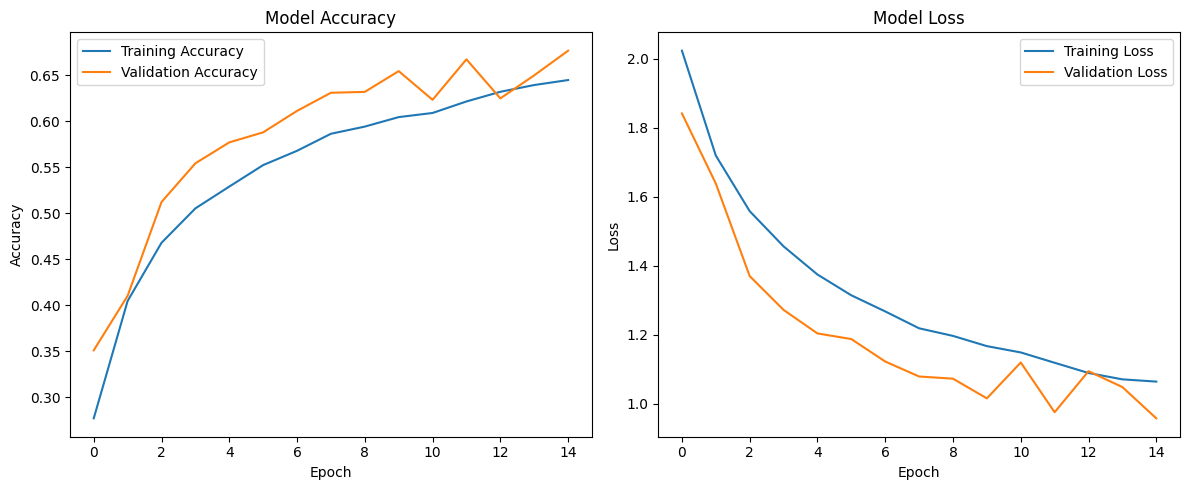

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluate the CNN Model

The trained CNN model is evaluated using the validation dataset to measure its overall classification performance.

In [ ]:
loss, accuracy = cnn_model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6764 - loss: 0.9572
Validation Loss: 0.9572
Validation Accuracy: 0.6764


## Generate Predictions

Predictions are generated on the validation dataset for further evaluation using a confusion matrix and classification report.

In [ ]:
import numpy as np

predictions = cnn_model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())

164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step


## Classification Report

The classification report provides precision, recall, F1-score, and support for each animal category.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

        cane       0.67      0.73      0.69       972
     cavallo       0.59      0.72      0.65       524
    elefante       0.48      0.75      0.59       289
    farfalla       0.60      0.88      0.71       422
     gallina       0.83      0.78      0.81       619
       gatto       0.72      0.36      0.48       333
       mucca       0.57      0.47      0.51       373
      pecora       0.67      0.54      0.60       364
       ragno       0.90      0.73      0.81       964
  scoiattolo       0.57      0.50      0.53       372

    accuracy                           0.68      5232
   macro avg       0.66      0.65      0.64      5232
weighted avg       0.70      0.68      0.67      5232



## Confusion Matrix

The confusion matrix visualizes the number of correct and incorrect predictions for each animal class.

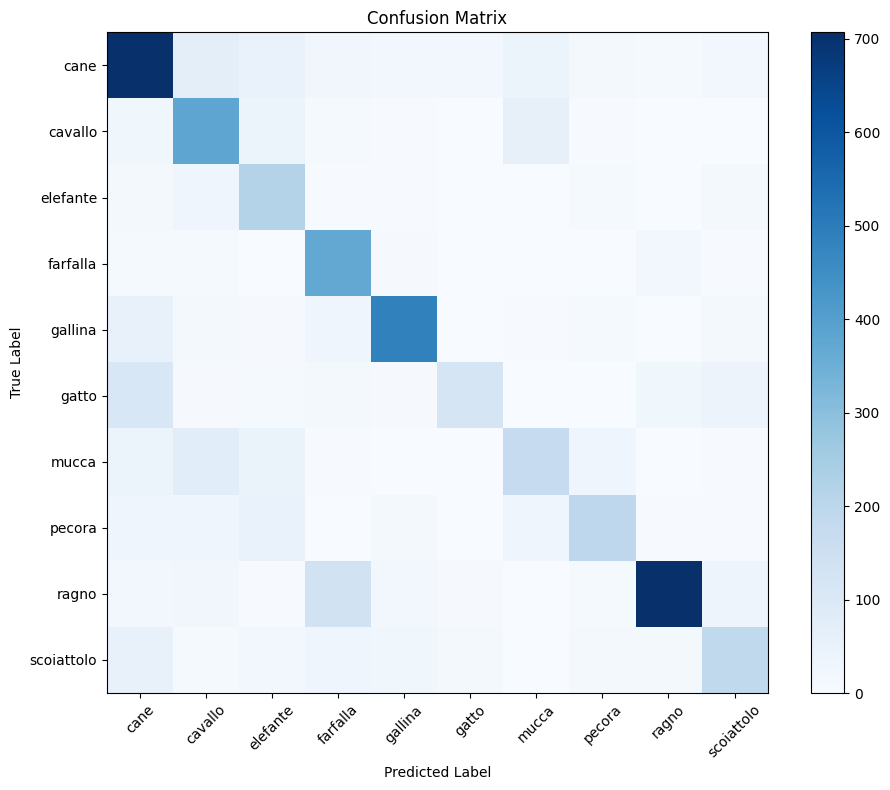

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(class_labels)), class_labels, rotation=45)
plt.yticks(range(len(class_labels)), class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

# Transfer Learning Using MobileNetV2

Transfer learning is implemented using the MobileNetV2 architecture pre-trained on the ImageNet dataset. The pre-trained model acts as a feature extractor, while a custom classification head is added for recognizing the ten animal species.

In [ ]:
IMG_SIZE_MOBILE = (224,224)
BATCH_SIZE = 32
SEED = 42

## Prepare Data for MobileNetV2

New data generators are created because MobileNetV2 requires input images of size 224 × 224 pixels.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_mobile = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.20,
    height_shift_range=0.20,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen_mobile = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

## Load Training Dataset

In [ ]:
train_generator_mobile = train_datagen_mobile.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE_MOBILE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

Found 20947 images belonging to 10 classes.


## Import MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

## Load the Pre-trained Model

The ImageNet pre-trained weights are used while keeping the feature extraction layers frozen.

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

## Build MobileNetV2 Classification Model

In [ ]:
mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

## Display Model Summary

In [ ]:
mobilenet_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Train MobileNetV2

In [ ]:
mobile_history = mobilenet_model.fit(
    train_generator_mobile,
    validation_data=validation_generator_mobile,
    epochs=10
)

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 343s 493ms/step - accuracy: 0.8695 - loss: 0.4189 - val_accuracy: 0.9495 - val_loss: 0.1607
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 300s 457ms/step - accuracy: 0.9051 - loss: 0.3065 - val_accuracy: 0.9515 - val_loss: 0.1561
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 288s 439ms/step - accuracy: 0.9113 - loss: 0.2738 - val_accuracy: 0.9442 - val_loss: 0.1744
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 289s 441ms/step - accuracy: 0.9156 - loss: 0.2624 - val_accuracy: 0.9547 - val_loss: 0.1493
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 290s 443ms/step - accuracy: 0.9191 - loss: 0.2493 - val_accuracy: 0.9503 - val_loss: 0.1529
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 282s 429ms/step - accuracy: 0.9233 - loss: 0.2373 - val_accuracy: 0.9536 - val_loss: 0.1477
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 282s 430ms/step - accuracy: 0.9222 - loss: 0.2370 - val_accuracy: 0.9585 - val_loss: 0.1372
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 278s 425ms/step - accuracy: 0.9239 -

## Plot Training History

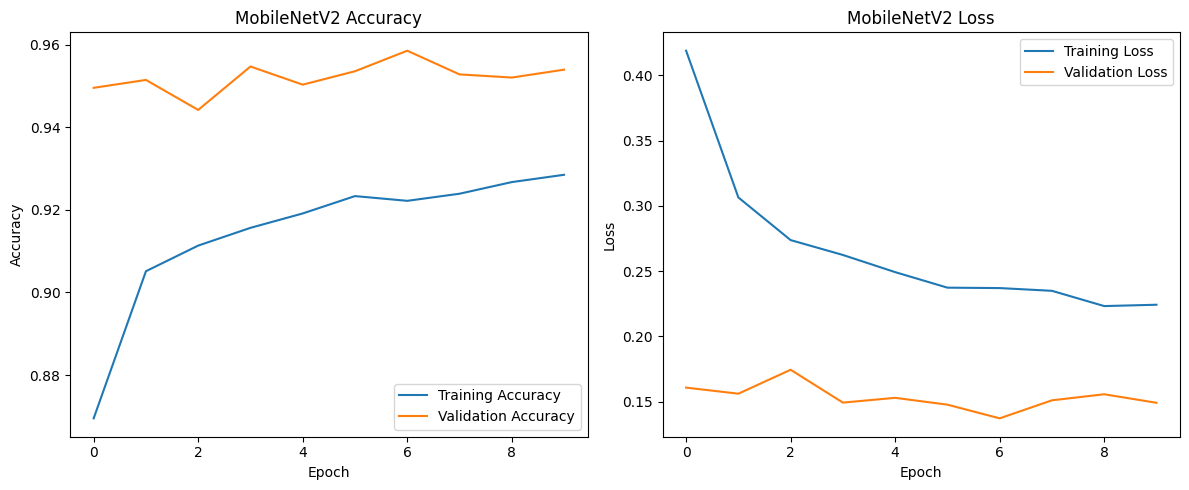

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(mobile_history.history['accuracy'], label='Training Accuracy')
plt.plot(mobile_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(mobile_history.history['loss'], label='Training Loss')
plt.plot(mobile_history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluate MobileNetV2

In [ ]:
mobile_loss, mobile_accuracy = mobilenet_model.evaluate(validation_generator_mobile)

print(f"Validation Accuracy: {mobile_accuracy:.4f}")
print(f"Validation Loss: {mobile_loss:.4f}")

164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9539 - loss: 0.1491
Validation Accuracy: 0.9539
Validation Loss: 0.1491


## Generate Predictions

In [ ]:
import numpy as np

mobile_predictions = mobilenet_model.predict(validation_generator_mobile)

mobile_predicted = np.argmax(mobile_predictions, axis=1)

true_classes = validation_generator_mobile.classes

class_labels = list(validation_generator_mobile.class_indices.keys())

164/164 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step


## Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    mobile_predicted,
    target_names=class_labels
))

              precision    recall  f1-score   support

        cane       0.96      0.96      0.96       972
     cavallo       0.94      0.95      0.95       524
    elefante       0.92      0.97      0.95       289
    farfalla       0.95      0.97      0.96       422
     gallina       0.99      0.98      0.98       619
       gatto       0.93      0.92      0.93       333
       mucca       0.87      0.95      0.91       373
      pecora       0.93      0.87      0.90       364
       ragno       0.99      0.98      0.98       964
  scoiattolo       0.97      0.92      0.94       372

    accuracy                           0.95      5232
   macro avg       0.95      0.95      0.95      5232
weighted avg       0.95      0.95      0.95      5232



## Confusion Matrix

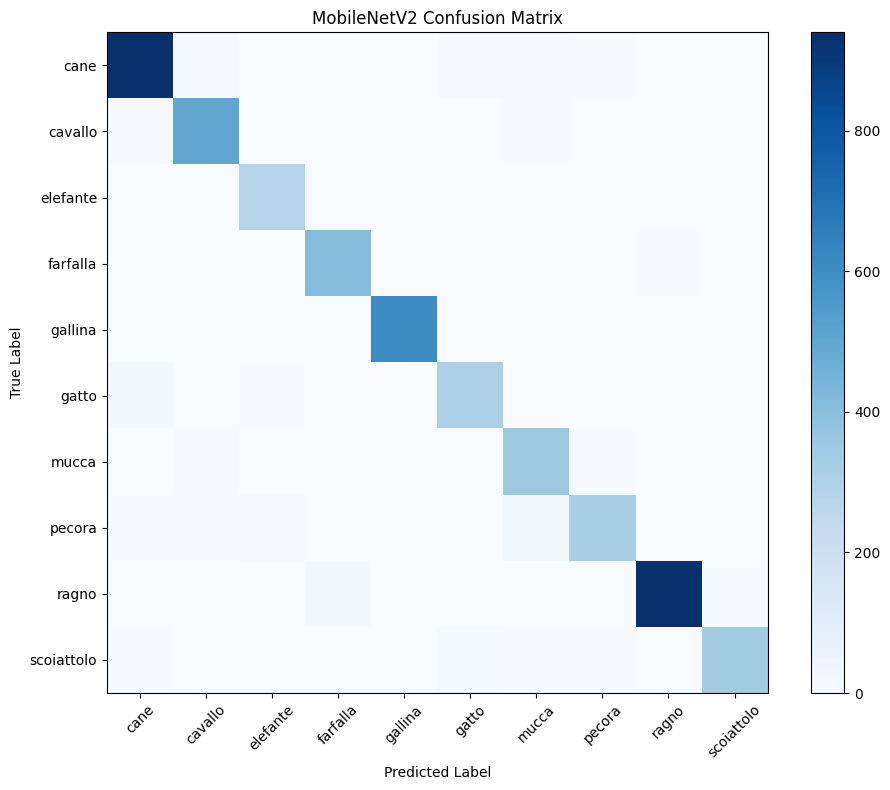

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, mobile_predicted)

plt.figure(figsize=(10,8))

plt.imshow(cm, cmap='Blues')
plt.title("MobileNetV2 Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(class_labels)), class_labels, rotation=45)
plt.yticks(range(len(class_labels)), class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

# Model Comparison

The performance of the Custom CNN and MobileNetV2 models is compared based on validation accuracy and validation loss. This comparison helps determine which model performs better for the animal species recognition task.

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Validation Accuracy": [0.6764, mobile_accuracy],
    "Validation Loss": [0.9572, mobile_loss]
})

comparison

,Model,Validation Accuracy,Validation Loss
0,Custom CNN,0.676400,0.957200
1,MobileNetV2,0.953937,0.149119


## Accuracy Comparison

The validation accuracy of both models is visualized using a bar chart.

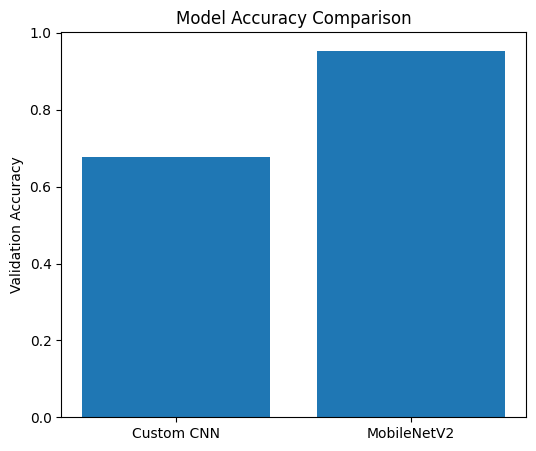

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    comparison["Model"],
    comparison["Validation Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Validation Accuracy")

plt.show()

## Validation Loss Comparison

The validation loss of both models is compared using a bar chart.

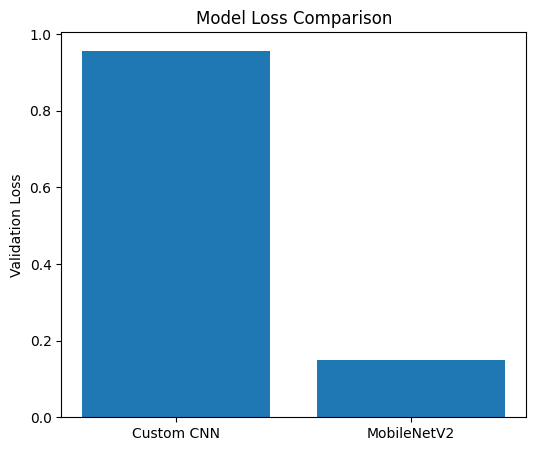

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    comparison["Model"],
    comparison["Validation Loss"]
)

plt.title("Model Loss Comparison")
plt.ylabel("Validation Loss")

plt.show()

# Save the Trained Models

The trained models are saved for future inference and deployment.

In [ ]:
cnn_model.save("CustomCNN.keras")

mobilenet_model.save("MobileNetV2.keras")

print("Models saved successfully.")

Models saved successfully.


# Project Conclusion

The project successfully created an animal species recognition framework, both with a custom CNN model and with the MobileNetV2 transfer learning model. The models were trained and tested in Animals-10. Validation accuracy, validation loss, confusion matrices and classification reports were used to assess performance. The comparison showed that deep learning approach works well in multi-class image classification and transfer learning is beneficial in image recognition tasks.

In [ ]:
print("="*50)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*50)

print(f"Custom CNN Accuracy      : {accuracy:.4f}")
print(f"Custom CNN Loss          : {loss:.4f}")

print(f"MobileNetV2 Accuracy     : {mobile_accuracy:.4f}")
print(f"MobileNetV2 Loss         : {mobile_loss:.4f}")

if mobile_accuracy > accuracy:
    print("\nBest Model : MobileNetV2")
else:
    print("\nBest Model : Custom CNN")

PROJECT COMPLETED SUCCESSFULLY
Custom CNN Accuracy      : 0.6764
Custom CNN Loss          : 0.9572
MobileNetV2 Accuracy     : 0.9539
MobileNetV2 Loss         : 0.1491

Best Model : MobileNetV2
